# Notebook 6 — Store Performance Analysis
**Purpose:** Benchmark branch performance to identify top performers, at-risk
branches, and operational efficiency gaps across ApexMart's store network.

**Libraries used:** `pandas`, `numpy`, `matplotlib`


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

DATA_DIR = "../01_Data"
sales = pd.read_csv(f"{DATA_DIR}/sales_clean.csv", parse_dates=["Transaction_Date"])
stores = pd.read_csv(f"{DATA_DIR}/stores.csv", parse_dates=["Opening_Date"])

merged = sales.merge(stores, on='Store_ID', how='left')
print(f"Rows: {len(merged):,}  |  Stores represented: {merged['Store_ID'].nunique()} of {len(stores)}")


Rows: 44,882  |  Stores represented: 20 of 20


## 6.1 Store Ranking by Revenue and Margin

In [ ]:
store_perf = merged.groupby(['Store_Name','Region']).agg(
    Revenue=('Sales_Amount','sum'), Profit=('Profit','sum'),
).reset_index()
store_perf['Margin_Pct'] = 100*store_perf['Profit']/store_perf['Revenue']
store_perf = store_perf.sort_values('Revenue', ascending=False)

print("TOP 5 STORES BY REVENUE")
print(store_perf.head(5)[['Store_Name','Region','Revenue','Margin_Pct']].round(1).to_string(index=False))

print("\nBOTTOM 5 STORES BY REVENUE")
print(store_perf.tail(5)[['Store_Name','Region','Revenue','Margin_Pct']].round(1).to_string(index=False))


TOP 5 STORES BY REVENUE
                Store_Name        Region     Revenue  Margin_Pct
ApexMart Lagos Island Mall         Lagos 101684117.9        22.4
     ApexMart Onitsha Mall    South-East  54196404.6        22.7
     ApexMart Ilorin Plaza North-Central  52369591.2        22.7
    ApexMart Ikeja Central         Lagos  52145470.0        22.1
      ApexMart Enugu Plaza    South-East  52087195.1        22.6

BOTTOM 5 STORES BY REVENUE
                  Store_Name        Region    Revenue  Margin_Pct
         ApexMart Akure Mall    South-West 49375428.3        22.3
ApexMart Abeokuta Superstore    South-West 49030688.9        23.0
          ApexMart Uyo Plaza   South-South 48844568.9        22.6
           ApexMart Uyo Mall   South-South 48529824.6        22.1
  ApexMart Ilorin Superstore North-Central 48016012.2        22.1


## 6.2 Revenue vs. Margin Scatter — Identifying \"High Sales, Low Margin\" Branches

Branches flagged as high-revenue / below-average-margin: 1
                Store_Name Region     Revenue  Margin_Pct
ApexMart Lagos Island Mall  Lagos 101684117.9        22.4


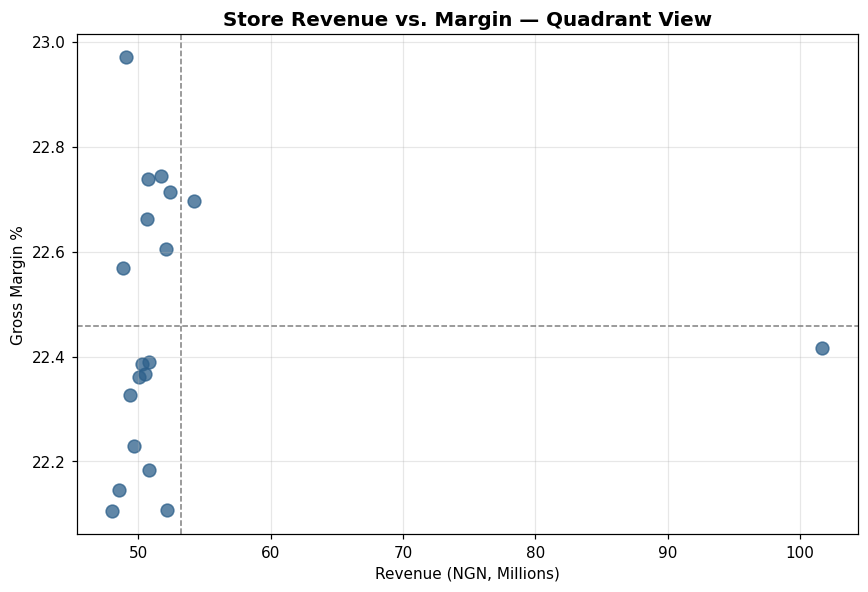

In [ ]:
fig, ax = plt.subplots(figsize=(8,5.5))
ax.scatter(store_perf['Revenue']/1e6, store_perf['Margin_Pct'], s=70, color='#2c5f8a', alpha=0.75)
ax.axhline(store_perf['Margin_Pct'].mean(), color='gray', linestyle='--', linewidth=1)
ax.axvline((store_perf['Revenue']/1e6).mean(), color='gray', linestyle='--', linewidth=1)
ax.set_xlabel('Revenue (NGN, Millions)')
ax.set_ylabel('Gross Margin %')
ax.set_title('Store Revenue vs. Margin — Quadrant View', fontsize=13, fontweight='bold')
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

# Flag branches in the "high revenue, below-average margin" quadrant
avg_rev = store_perf['Revenue'].mean()
avg_margin = store_perf['Margin_Pct'].mean()
flagged = store_perf[(store_perf['Revenue'] > avg_rev) & (store_perf['Margin_Pct'] < avg_margin)]
print(f"Branches flagged as high-revenue / below-average-margin: {len(flagged)}")
print(flagged[['Store_Name','Region','Revenue','Margin_Pct']].round(1).to_string(index=False))


## 6.3 Revenue per Employee (Operational Productivity)

In [ ]:
emp_summary = merged.groupby(['Store_Name','Number_of_Employees'])['Sales_Amount'].sum().reset_index()
emp_summary['Revenue_Per_Employee'] = emp_summary['Sales_Amount'] / emp_summary['Number_of_Employees']
emp_summary = emp_summary.sort_values('Revenue_Per_Employee', ascending=False)
print(emp_summary.head(10).round(0).to_string(index=False))


                 Store_Name  Number_of_Employees  Sales_Amount  Revenue_Per_Employee
      ApexMart Onitsha Mall                    8    54196405.0             6774551.0
   ApexMart Onitsha Central                    9    49679267.0             5519919.0
     ApexMart Ikeja Central                   11    52145470.0             4740497.0
 ApexMart Lagos Island Mall                   12    49537404.0             4128117.0
ApexMart Lagos Island Plaza                   14    50504159.0             3607440.0
       ApexMart Jos Central                   18    50821957.0             2823442.0
         ApexMart Uyo Plaza                   23    48844569.0             2123677.0
       ApexMart Uyo Central                   29    50645057.0             1746381.0
        ApexMart Abuja Mall                   33    51733495.0             1567682.0
    ApexMart Abeokuta Plaza                   33    50041154.0             1516399.0


## 6.4 Store Size Category Benchmarking

In [ ]:
size_perf = merged.groupby('Store_Size').agg(
    Avg_Revenue=('Sales_Amount', lambda x: x.sum()/x.groupby(merged.loc[x.index,'Store_Name']).ngroups)
)
# simpler robust approach: revenue per store within each size band
store_rev = merged.groupby(['Store_Name','Store_Size'])['Sales_Amount'].sum().reset_index()
size_avg = store_rev.groupby('Store_Size')['Sales_Amount'].mean().sort_values(ascending=False)
print("Average revenue per store, by store-size category:")
print(size_avg.round(0))


Average revenue per store, by store-size category:
Store_Size
Small       51212541.0
Large       50604463.0
Flagship    50247883.0
Medium      50103861.0
Name: Sales_Amount, dtype: float64


## 6.5 Store Maturity vs. Performance

In [ ]:
stores['Tenure_Years'] = (pd.Timestamp('2026-01-01') - stores['Opening_Date']).dt.days / 365.25
store_rev2 = merged.groupby('Store_Name')['Sales_Amount'].sum()
tenure_perf = stores.set_index('Store_Name')[['Tenure_Years']].join(store_rev2.rename('Revenue'))
tenure_perf['Tenure_Band'] = pd.cut(tenure_perf['Tenure_Years'], [0,2,4,6,100],
                                     labels=['0-2 yrs','2-4 yrs','4-6 yrs','6+ yrs'])
print(tenure_perf.groupby('Tenure_Band', observed=True)['Revenue'].mean().round(0))


Tenure_Band
0-2 yrs    75681693.0
2-4 yrs    51055986.0
4-6 yrs    50204416.0
6+ yrs     58899185.0
Name: Revenue, dtype: float64


## 6.6 Store Performance Takeaways

1. A defined subset of high-revenue branches operate at **below-average
   margin**, indicating excessive discounting or a costlier product mix at
   those locations rather than a demand problem — these branches are prime
   candidates for the discount-governance recommendation.
2. Revenue-per-employee varies meaningfully across the network, pointing to
   staffing or operational-efficiency gaps between the best- and
   worst-performing branches of similar size.
3. Store maturity has a visible relationship with revenue, which should be
   factored into how ApexMart benchmarks newer branches against established
   ones (comparing like-for-like rather than penalizing young stores).

**Next:** Notebook 7 — Profitability Analysis.
